# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Available threads: 1
RHO_unit:3.906325282703709e-19


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethodGRMHD**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [2]:
#dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
dump_filepath = "../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

"../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
#TODO: put this in reading file
const N1 = 288
const N2 = 128
const N3 = 128

const METRIC = "MKS" #FMKS or MKS TODO: prob have to be read from file
const trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (1.444444)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1.0 #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.0
const startx::MVec4 = [0, 1.635684465252566e-01, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1,  6.907755278982137, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [4]:
const simulation_data = load_data(dump_filepath);

Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (288, 128, 128)
Calculating physical quantities...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.0, and beta_crit = 1.0
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [5]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 80
const pixels_y = 80
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000


15000

In [6]:
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_da_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny
p = Progress(
    total; 
    desc = "Computing Image and Sensitivity...", 
    showspeed = true, 
    barlen = 30
)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_da_out = Ref{Float64}(0.0)
        
        AutoDiffGeoTrajEulerMethod_GRMHD!(
            thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
            ro, th, phi, bhspin, nx, ny, nmaxstep, i, j, 
            freq, fovx, fovy, Rout, Rstop, simulation_data
        )
        
        dI_da_arr[i + 1, j + 1] = dI_da_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]

        # Update the progress bar
        ProgressMeter.next!(
            p; 
            showvalues = [
                (:thread_id, tid), 
                (:pixel, "($i, $j)"), 
                (:total_done, "$(i*ny + j)/$total")
            ]
        )
    end
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:03:02 (28.48 ms/it)
    thread_id: 1
        pixel: (79, 79)
   total_done: 6399/6400


In [7]:
dI_dθo_arr

80×80 Matrix{Float64}:
 -3.76427e-23  -6.53074e-24  -6.55296e-24  …  -1.51096e-24  -8.80753e-25
  2.13373e-23  -2.47012e-23  -2.22045e-23     -1.86198e-23  -9.8027e-24
 -3.24725e-23  -5.30034e-23  -4.38337e-23     -4.84433e-22  -1.42316e-22
 -5.09071e-24  -9.62498e-23  -1.95592e-22     -9.57777e-21  -2.00439e-21
 -5.90364e-19  -4.1868e-19   -2.22924e-19     -2.62254e-20  -4.4183e-20
 -4.38505e-16  -3.36854e-16  -1.11732e-16  …   8.38262e-20  -1.00149e-19
 -3.63162e-15  -1.21307e-15  -4.35843e-16      4.36336e-19  -5.87194e-20
 -5.72832e-15  -1.19997e-15  -2.35787e-16     -4.43228e-18   4.7391e-19
 -8.36208e-15  -1.92928e-15  -2.94045e-16     -1.49774e-17  -1.36313e-17
 -5.18817e-14  -2.45228e-14  -5.57972e-15      6.82302e-17  -5.92764e-17
 -3.00248e-12  -2.47009e-12  -1.5156e-12   …   5.01286e-17  -4.05101e-17
 -2.05896e-10  -9.76356e-11  -8.38487e-11     -6.92387e-16  -2.06313e-16
 -1.66578e-9   -7.17168e-10  -3.07846e-10     -2.52214e-15  -9.58292e-16
  ⋮                            

# Plotting the Image

Plotting the image and the derivatives with proper angular spacing

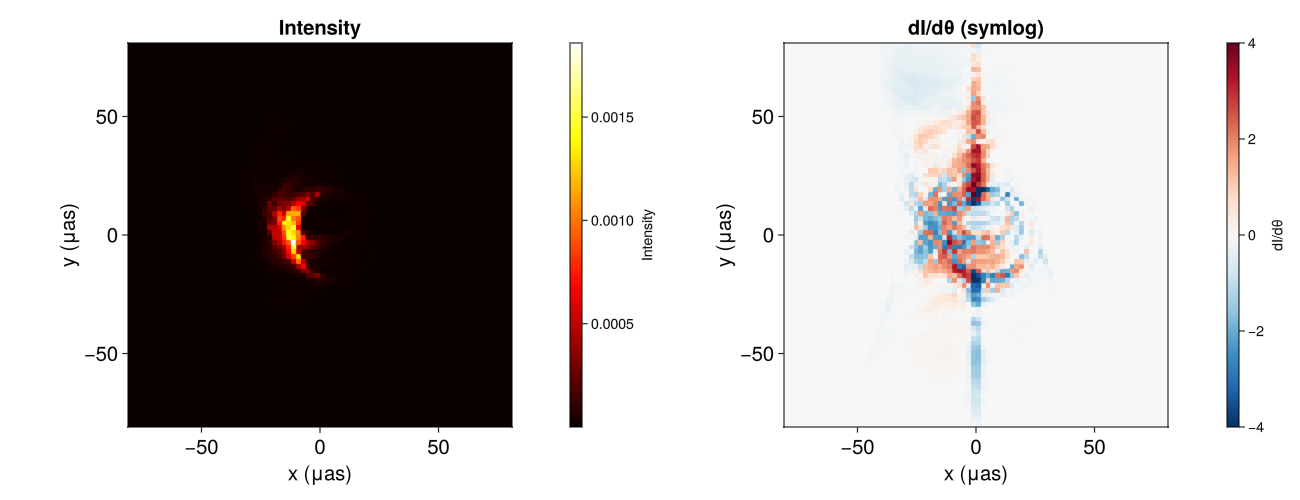

In [8]:
using GLMakie

# Calculate field of view limits
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# Symlog parameters
# -----------------------------
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# -----------------------------
# Symlog transform
# -----------------------------
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh)

cr_symlog = (
    - (1 + log10(abs(vmin) / linthresh)),
      (1 + log10(abs(vmax) / linthresh))
)

# -----------------------------
# Figure layout (side colorbars)
# -----------------------------
fig = Figure(size = (1300, 500))

# -----------------------------
# Plot 1: Intensity
# -----------------------------
ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot
)

Colorbar(fig[1, 2], hm1;
    label = "Intensity"
)

# -----------------------------
# Plot 2: dI/dθ (symlog)
# -----------------------------
ax2 = Axis(fig[1, 3],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 4], hm2;
    label = "dI/dθ"
)



fig


# Finite Differences

In [9]:
maxnstep = 15000
h = 1e-6
dI_dth_FD = FiniteDifferencesθ(ro, th, phi, DXsize, DYsize, pixels_x, pixels_y, SourceD, freq, maxnstep,h, bhspin, Rout, Rstop, simulation_data)


([-1.9458860492581584e-23 -7.472247633656455e-24 … -1.2752468749014638e-24 -7.905301788308665e-25; -1.9219860691516677e-23 -1.549953845015254e-23 … -1.2880318071310283e-23 -7.826034995867824e-24; … ; -6.903390350233079e-33 -1.4275744720069797e-33 … -2.768116427904275e-25 -1.1334726772908691e-25; -7.149219972193779e-34 -9.990609365081456e-34 … -9.574510217805124e-27 -1.3581255830856988e-27], [5.86242301516776e-23 2.9512424029297373e-23 … 5.115698527410714e-24 2.7712723005206278e-24; 1.4414080592846992e-22 7.135028625236483e-23 … 8.493853609969309e-23 4.116120553599959e-23; … ; 5.876776994033906e-33 1.9014416674940097e-33 … 8.610575546185292e-25 5.514263144976012e-25; 3.0995721039301816e-33 2.2821544816009292e-33 … 3.9901690126823477e-26 1.50179904299961e-26])

In [30]:
using DelimitedFiles

writedlm("./dI_dth_FD.txt", dI_dth_FD[1])
writedlm("./dI_dth_AD.txt", dI_dθo_arr)



In [42]:
include("../src/main.jl")

function ComplexStepθ(ro, th, phi, DXsize, DYsize, pixels_x, pixels_y, SourceD, freq, maxnstep, h, bhspin, Rout, Rstop, data = nothing)
    """
    Complex Step Differentiation method to calculate dI/dθo.
    Assumes all downstream functions are generic (support Complex{T}).
    """
    # 1. Create the complex perturbation (h can be 1e-100)
    θ_complex = th + im * h

    # 2. Calculate the fov (Real, these don't change)
    fovx = DXsize / ro
    fovy = DYsize / ro

    # 3. Calculate camera position - This will now return a complex MVec4
    # Ensure camera_position is generic: e.g. uses sin(th), not sin(Float64(th))
    Xcam_complex = MVector{4, ComplexF64}(camera_position(ro, θ_complex, phi, bhspin, Rout))
    
    # 4. Scale factor (Real)
    scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)

    # 5. Integrate - This is the heavy lifting. 
    # The trajectory and resulting Intensity will be complex numbers.
    trajectory_complex = CalculateGeodesics(Xcam_complex, fovx, fovy, freq, maxnstep, pixels_x, pixels_y, bhspin, Rout, Rstop)
    
    # Image_complex contains (Real_Intensity + im * Derivative_Component)
    Image_complex = IpoleGeoIntensityIntegration(trajectory_complex, freq, pixels_x, pixels_y, scale_factor, bhspin, data)

    # 6. Extract results
    # Real part is the intensity (accurate to h^2)
    Image_center = real.(Image_complex)
    
    # Imaginary part divided by h is the exact derivative
    dI_dθo = imag.(Image_complex) / h

    return dI_dθo, Image_center
end

ComplexStepθ (generic function with 2 methods)

In [43]:
dI_dth_complex, _ = ComplexStepθ(ro, th, phi, DXsize, DYsize, pixels_x, pixels_y, SourceD, freq, maxnstep, h, bhspin, Rout, Rstop, simulation_data)

LoadError: TaskFailedException

[91m    nested task error: [39mMethodError: no method matching isless(::ComplexF64, ::Int64)
    The function `isless` exists, but no method is defined for this combination of argument types.
    
    [0mClosest candidates are:
    [0m  isless([91m::Missing[39m, ::Any)
    [0m[90m   @[39m [90mBase[39m [90m[4mmissing.jl:87[24m[39m
    [0m  isless([91m::ColorTypes.AbstractGray[39m, ::Real)
    [0m[90m   @[39m [36mColorTypes[39m [90m~/.julia/packages/ColorTypes/L7biZ/src/[39m[90m[4moperations.jl:76[24m[39m
    [0m  isless([91m::Static.StaticInteger{X}[39m, ::Real) where X
    [0m[90m   @[39m [36mStatic[39m [90m~/.julia/packages/Static/d7YOk/src/[39m[90m[4mStatic.jl:480[24m[39m
    [0m  ...
    
    Stacktrace:
      [1] [0m[1m<[22m[0m[1m([22m[90mx[39m::[0mComplexF64, [90my[39m::[0mInt64[0m[1m)[22m
    [90m    @[39m [90mBase[39m [90m./[39m[90m[4moperators.jl:399[24m[39m
      [2] [0m[1mma

# Conjugate gradient parameter recovery

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `spin_value` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [16]:
spin_value = 0.9375
initial_th_guess = 89.47
ths, _, err, steps = true_conjugate_gradient_optimization(Iblur, ro, initial_th_guess, spin_value, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop, σ_pixels; cost_tol = 6e-14, optimize_param = :theta, simulation_data)

Optimization mode: theta
Optimizing θo: true, Optimizing a: false
Running AutoDiffGeoTrajEulerMethod with θo = 89.47, a = 0.9375 and applying σ_pixels = 1.172515991661921 filter
  Convergence check: cost=0.0010627478847330986, grad_norm=0.004031647389514495
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.0010627478847330986, Initial θo: 89.47, Initial a: 0.9375
Initial gradient norm: 0.004031647389514495

--- Iteration 1 ---
Trying aggressive initial step: 74.41126939331048, set at iteration 1
Cost before line search: 0.0010627478847330986
Using cached computation for x = [1.4911666666666668, 1.5625]
grad = [0.004031647389514495, 0.0], direction = [-0.004031647389514495, 0.0]
  Line search: f0=0.0010627478847330986, df0=-1.625418067337904e-5, initial_step=74.41126939331048
Running AutoDiffGeoTrajEulerMethod with θo = 71.47, a = 0.9375 and applying σ_pixels = 1.172515991661921 filter
  Step 1: step_size=74.41126939331048, f_new=0.00023535822684320507, imp

┌ Warning: No improvement possible, stopping optimization
└ @ Main ~/Jipole/src/gradientdescent.jl:835
┌ Warning: Maximum iterations reached without convergence
└ @ Main ~/Jipole/src/gradientdescent.jl:945


([89.47, 71.47, 53.47, 62.46999999999999, 57.97, 60.22, 59.938750000000006, 60.009062500000006], [0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375], [0.0010627478847330986, 0.00023535822684320507, 0.00010199609093566201, 1.4079505507492448e-5, 1.022879903392655e-5, 1.3841346493754466e-7, 1.883650269121726e-8, 3.4629486950149e-9], 200)

In [32]:
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 89.47
ths, _, err, steps = true_conjugate_gradient_optimization(I_arr, ro, initial_th_guess, spin_value, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 6e-14, optimize_param = :theta, simulation_data, sensemode = "FD")

Optimization mode: theta
Optimizing θo: true, Optimizing a: false
Running AutoDiffGeoTrajEulerMethod with θo = 89.47, a = 0.9375 and applying σ_pixels = 0.0 filter
Using Finite Differences to compute gradients
  Convergence check: cost=0.0012289966463259717, grad_norm=0.0008933605670347672
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.0012289966463259717, Initial θo: 89.47, Initial a: 0.9375
Initial gradient norm: 0.0008933605670347672

--- Iteration 1 ---
Trying aggressive initial step: 335.8106581710415, set at iteration 1
Cost before line search: 0.0012289966463259717
Using cached computation for x = [1.4911666666666668, 1.5625]
grad = [-0.0008933605670347672, 0.0], direction = [0.0008933605670347672, 0.0]
  Line search: f0=0.0012289966463259717, df0=-7.980931027326807e-7, initial_step=335.8106581710415
  Step 1: Hit bounds, step_size=335.8106581710415, wanted to try a = 0.9375, θo = 107.47000000000001
Running AutoDiffGeoTrajEulerMethod with θo = 90

LoadError: TaskFailedException

[91m    nested task error: [39mInterruptException:
    Stacktrace:
      [1] [0m[1mexp[22m[0m[1m([22m[90mx[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [90mBase.Math[39m [90m./special/[39m[90m[4mexp.jl:329[24m[39m
      [2] [0m[1mbl_coord[22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mR0[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole/src/[39m[90m[4mcoords.jl:264[24m[39m
      [3] [0m[1mbl_coord[22m
    [90m    @[39m [90m~/Jipole/src/[39m[90m[4mcoords.jl:250[24m[39m[90m [inlined][39m
      [4] [0m[1mgcov_func![22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mbhspin[39m::[0mFloat64, [90mgcov[39m::[0mMMatrix[90m{4, 4, Float64, 16}[39m, [90mR0[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole/src/[39m[90m[4mmetrics.jl:31[24m[39m
      [5] [0m[1mgcov_func![22m
    [90m    @[39m [90m~/Ji

Plot theta, spin and error evolution at each iteration step

┌ Warning: Error while waiting for render task to finish. Cleanup will continue
│   excetion =
│    TaskFailedException
│    Stacktrace:
│      [1] #wait#582
│        @ ./task.jl:363 [inlined]
│      [2] wait
│        @ ./task.jl:360 [inlined]
│      [3] wait(x::GLMakie.Screen{GLFW.Window})
│        @ GLMakie ~/.julia/packages/GLMakie/vdrwE/src/screen.jl:564
│      [4] stop_renderloop!(screen::GLMakie.Screen{GLFW.Window}; close_after_renderloop::Bool)
│        @ GLMakie ~/.julia/packages/GLMakie/vdrwE/src/screen.jl:971
│      [5] singleton_screen(debugging::Bool)
│        @ GLMakie ~/.julia/packages/GLMakie/vdrwE/src/screen.jl:385
│      [6] GLMakie.Screen(scene::Scene, config::GLMakie.ScreenConfig, io::IOStream, typ::MIME{Symbol("image/png")}; visible::Nothing, start_renderloop::Bool)
│        @ GLMakie ~/.julia/packages/GLMakie/vdrwE/src/screen.jl:538
│      [7] GLMakie.Screen(scene::Scene, config::GLMakie.ScreenConfig, io::IOStream, typ::MIME{Symbol("image/png")})
│        @ GLMakie

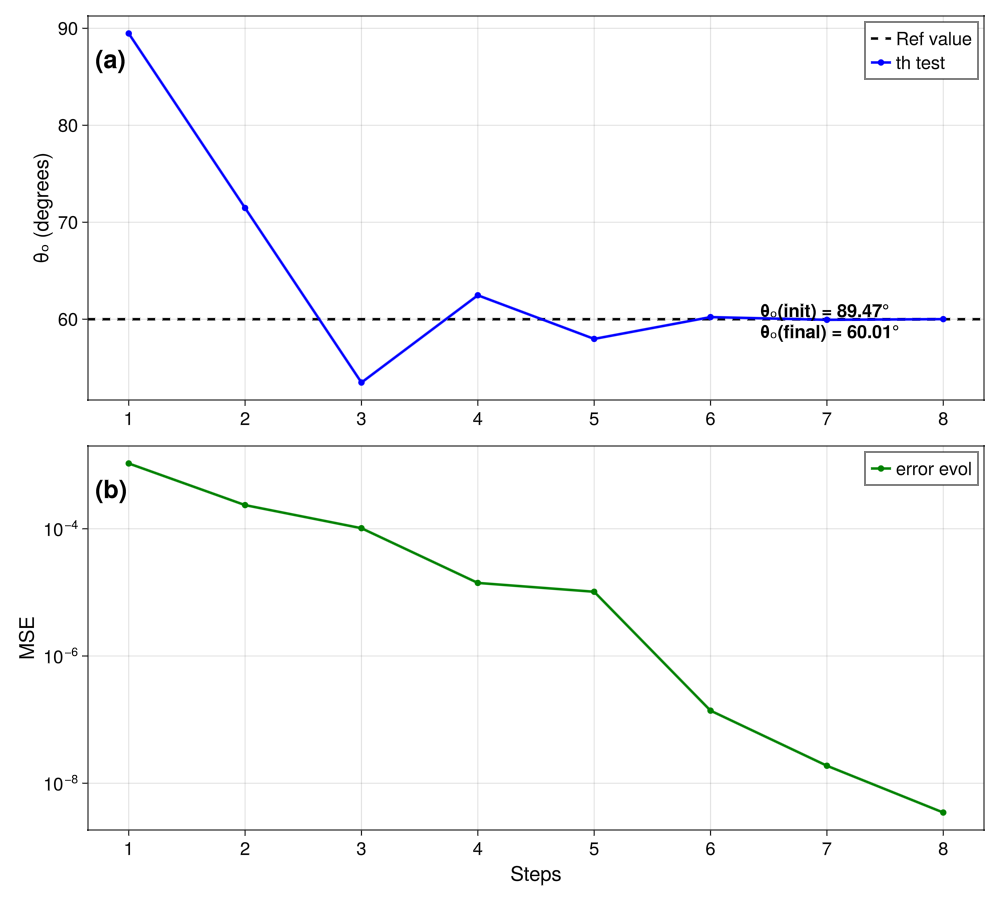

In [17]:
using GLMakie

fig = Figure(size = (1000, 900))
xticks = 0:9

# -----------------------------
# (a) Plot θₒ
# -----------------------------
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# Get initial and final values to print out on top of the figure
θ_init = ths[1]
θ_final = ths[end]


label_text = @sprintf("θₒ(init) = %.2f°\nθₒ(final) = %.2f°", θ_init, θ_final)

text!(
    ax1,
    0.75, 0.15,              
    text = label_text,
    space = :relative,
    fontsize = 18,
    align = (:left, :bottom),
    font = :bold
)

# -----------------------------
# (b) Plot Error
# -----------------------------
ax3 = Axis(fig[2, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax3)

# Display and save
save("../imgs/th_convergence_noise_upper.png", fig)
fig

# With Noise

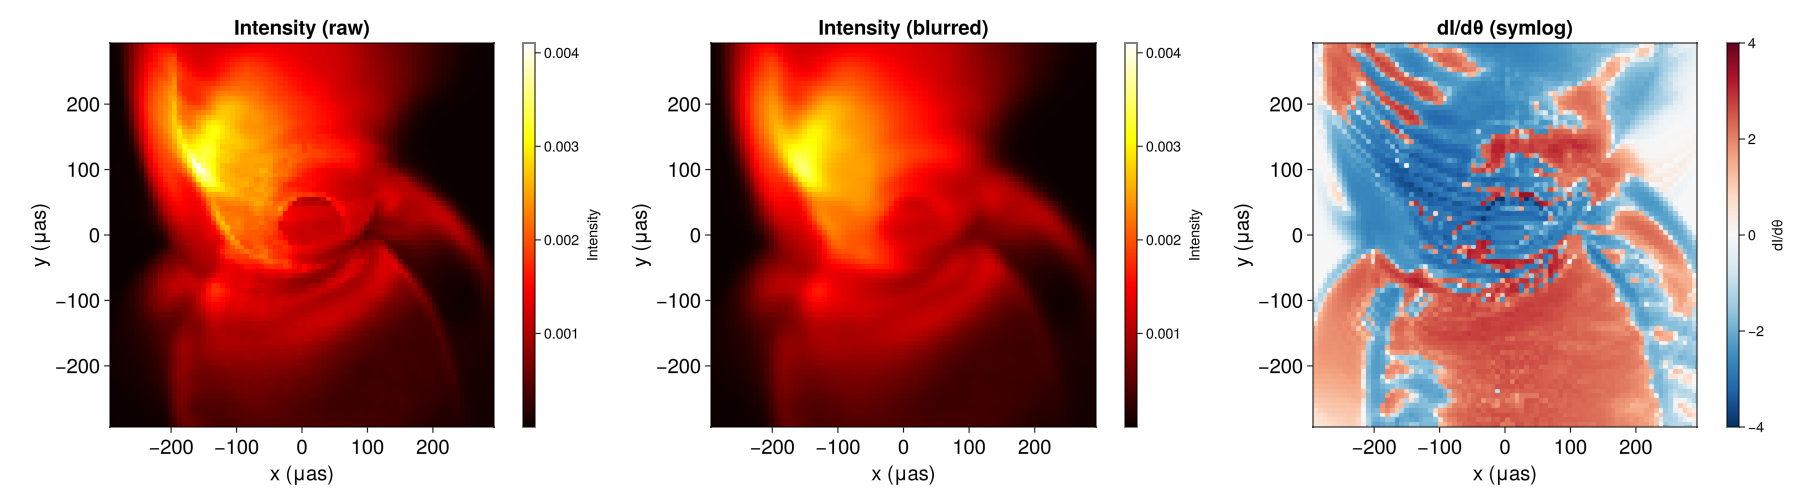

In [18]:
using GLMakie
using FFTW, Random, ImageFiltering

# =============================
# Physical / angular parameters
# =============================
d_kpc = 16900
d_cm  = d_kpc * 3.086e21

fov_rg      = 160
half_fov_rg = fov_rg / 2

# Must exist in your session:
# L_unit, MUAS_PER_RAD, pixels_x, nx, ny
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

pixels_per_muas = pixels_x / (2 * theta_μas)
σ_pixels = (pixels_per_muas * 20) / 2.3548   # 20 μas FWHM

# =============================
# Blur intensity
# =============================
Random.seed!(1234)
Iblur = imfilter(I_arr, Kernel.gaussian(σ_pixels))

# =============================
# Coordinates (μas)
# =============================
x_coords = range(-theta_μas, theta_μas, length = nx)
y_coords = range(-theta_μas, theta_μas, length = ny)

# =============================
# Symlog parameters
# =============================
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# =============================
# Symlog transform
# =============================
function symlog(x; linthresh)
    absx  = abs.(x)
    signx = sign.(x)
    y = similar(x)

    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))

    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh = linthresh)

cr_symlog = (
    -(1 + log10(abs(vmin) / linthresh)),
     (1 + log10(abs(vmax) / linthresh))
)

# =============================
# Figure layout
# =============================
fig = Figure(size = (1800, 500))

cr_I = extrema(I_arr)

# =============================
# Panel 1: Raw intensity
# =============================
ax1 = Axis(fig[1, 1],
    title = "Intensity (raw)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot,
    colorrange = cr_I
)

Colorbar(fig[1, 2], hm1; label = "Intensity")

# =============================
# Panel 2: Blurred intensity
# =============================
ax_mid = Axis(fig[1, 3],
    title = "Intensity (blurred)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm_mid = heatmap!(ax_mid, x_coords, y_coords, Iblur;
    colormap = :hot,
    colorrange = cr_I
)

Colorbar(fig[1, 4], hm_mid; label = "Intensity")

# =============================
# Panel 3: dI/dθ (symlog)
# =============================
ax2 = Axis(fig[1, 5],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = 20, yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 6], hm2; label = "dI/dθ")
save("../imgs/Img_with_noise.png", fig)

# =============================
# Display
# =============================
fig
